# CTR Impact Features

By Yusuf

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('C:/Tempa_dicoding\projek_akhir\Model-Prediksi-dan-Diagnosa-Penurunan-Views-YouTube-Berbasis-Machine-Learning/data/raw/hippo_academy_raw.csv')
df.head()

,views,impressions,ctr(%),avg_view_duration,video_duration_sec,likes,comments,subscribers_gained,subscribers_lost,revenue_idr,publish_date,video_title
0,7225.0,26219.0,24.58,0:05:08,600.0,0.0,0.0,1.0,0.0,NaN,2026-05-08,"MALAYSIA COLLAPSE! BANGLADESH MENGAMUK, EKONOM..."
1,9831.0,32708.0,26.14,0:04:41,600.0,0.0,0.0,1.0,0.0,9785.004,2026-05-08,RINGGIT ANJLOK PARAH! WARGA MALAYSIA RAMAI-RAM...
2,4177.0,16230.0,19.19,0:04:00,600.0,0.0,0.0,-2.0,0.0,20188.040,2026-05-07,SKANDAL BUSUK TERUNGKAP! RAJA MALAYSIA COBA HA...
3,4948.0,20597.0,19.64,0:04:38,600.0,0.0,0.0,0.0,0.0,25235.700,2026-05-06,HINA INDONESIA MISKIN! RINGGIT BENAR-BENAR TAK...
4,7111.0,28245.0,21.64,0:04:38,600.0,0.0,0.0,1.0,0.0,38440.217,2026-05-06,PETRONAS BANGKRUT?! DPR DAN RAJA MALAYSIA NGAM...


## 1. Impression to View Rate
impression_to_view_rate = views / impressions

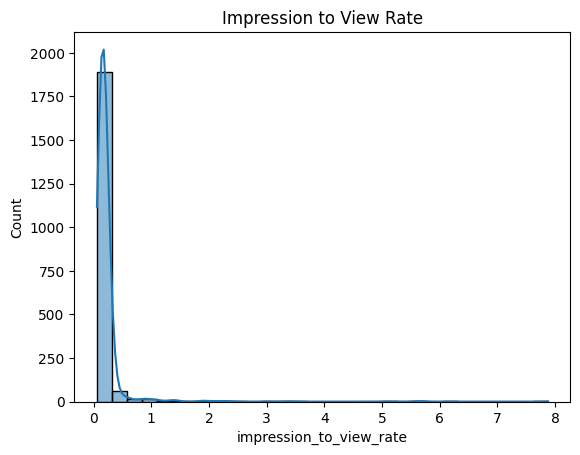

In [5]:
df['impression_to_view_rate'] = df['views'] / (df['impressions'] + 1)
sns.histplot(df['impression_to_view_rate'], bins=30, kde=True)
plt.title('Impression to View Rate')
plt.show()

## 2. CTR Normalized
ctr_normalized = ctr / 100

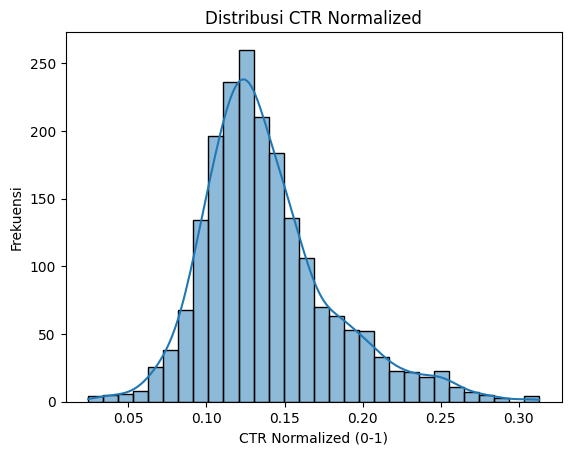

count    2004.000000
mean        0.138951
std         0.041771
min         0.024300
25%         0.111800
50%         0.131000
75%         0.158550
max         0.313000
Name: ctr_normalized, dtype: float64


In [8]:
df['ctr_normalized'] = df['ctr(%)'] / 100

sns.histplot(df['ctr_normalized'], bins=30, kde=True)
plt.title('Distribusi CTR Normalized')
plt.xlabel('CTR Normalized (0-1)')
plt.ylabel('Frekuensi')
plt.show()

print(df['ctr_normalized'].describe())

## 3. CTR Impression Score
ctr_impression_score = ctr_normalized * impression_to_view_rate

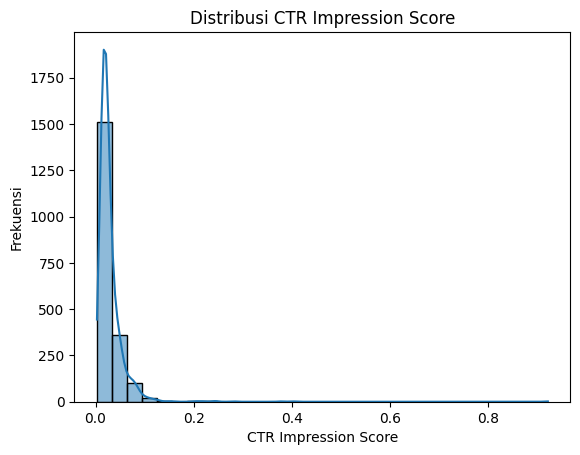

count    2004.000000
mean        0.029263
std         0.031963
min         0.002870
25%         0.015944
50%         0.021624
75%         0.033037
max         0.921457
Name: ctr_impression_score, dtype: float64


In [9]:
df['ctr_impression_score'] = df['ctr_normalized'] * df['impression_to_view_rate']

sns.histplot(df['ctr_impression_score'], bins=30, kde=True)
plt.title('Distribusi CTR Impression Score')
plt.xlabel('CTR Impression Score')
plt.ylabel('Frekuensi')
plt.show()

print(df['ctr_impression_score'].describe())

## 4. CTR Category
ctr_category = bin ctr into Low(<3%), Mid(3-7%), High(>7%)

In [10]:
df['ctr_category'] = pd.cut(
    df['ctr(%)'],
    bins=[0, 3, 7, float('inf')],
    labels=['Low', 'Mid', 'High'],
    right=True
)

print(df['ctr_category'].value_counts())

ctr_category
High    1965
Mid       37
Low        2
Name: count, dtype: int64


### CTR Category Analysis

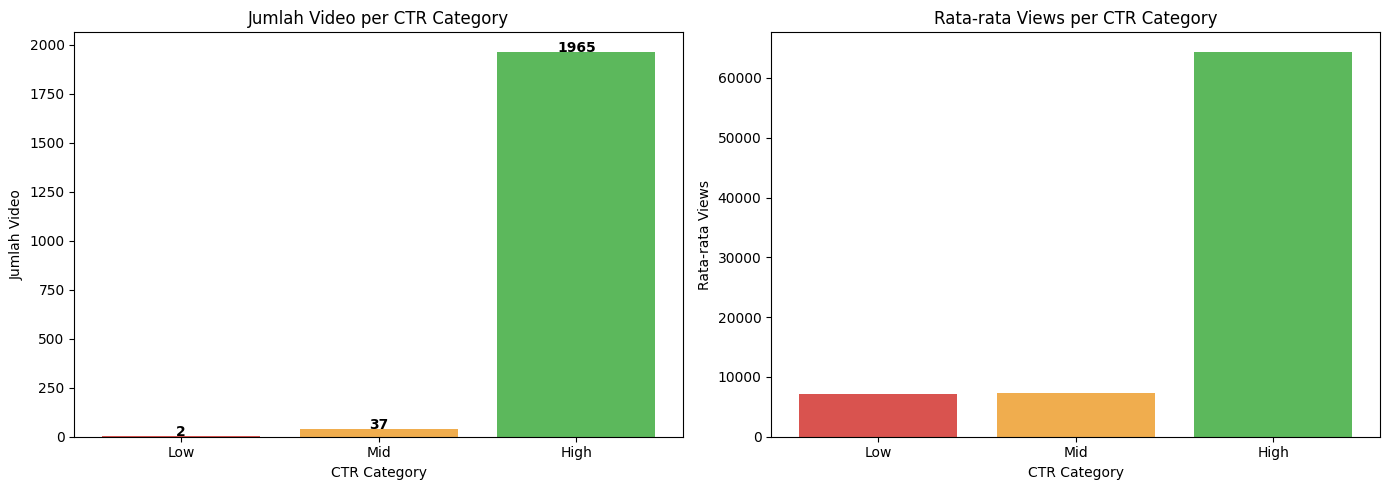


Statistik Views per CTR Category:
               count      mean        std     min      25%      50%       75%  \
ctr_category                                                                    
Low              2.0   7169.50     746.00  6642.0  6905.75   7169.5   7433.25   
Mid             37.0   7245.84    7102.65   296.0  1684.00   5542.0  11603.00   
High          1965.0  64416.65  761433.71   308.0  6652.00  13459.0  31722.00   

                     max  
ctr_category              
Low               7697.0  
Mid              27208.0  
High          22781869.0  


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ctr_counts = df['ctr_category'].value_counts().reindex(['Low', 'Mid', 'High'])
axes[0].bar(ctr_counts.index, ctr_counts.values, color=['#d9534f', '#f0ad4e', '#5cb85c'])
axes[0].set_title('Jumlah Video per CTR Category')
axes[0].set_xlabel('CTR Category')
axes[0].set_ylabel('Jumlah Video')
for i, v in enumerate(ctr_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

avg_views = df.groupby('ctr_category', observed=True)['views'].mean().reindex(['Low', 'Mid', 'High'])
axes[1].bar(avg_views.index, avg_views.values, color=['#d9534f', '#f0ad4e', '#5cb85c'])
axes[1].set_title('Rata-rata Views per CTR Category')
axes[1].set_xlabel('CTR Category')
axes[1].set_ylabel('Rata-rata Views')

plt.tight_layout()
plt.show()

print("\nStatistik Views per CTR Category:")
print(df.groupby('ctr_category', observed=True)['views'].describe().round(2))

In [ ]:
fitur_baru = ['impression_to_view_rate', 'ctr_normalized', 'ctr_impression_score', 'ctr_category']
print("Kolom setelah feature engineering:")
print(df.columns.tolist())
print(f"\nTotal kolom: {df.shape[1]}")
print(f"Total baris: {df.shape[0]}")
print("\nSample 5 baris fitur baru:")
df[fitur_baru].head()

Kolom setelah feature engineering:
['views', 'impressions', 'ctr(%)', 'avg_view_duration', 'video_duration_sec', 'likes', 'comments', 'subscribers_gained', 'subscribers_lost', 'revenue_idr', 'publish_date', 'video_title', 'impression_to_view_rate', 'ctr_normalized', 'ctr_impression_score', 'ctr_category']

Total kolom: 16
Total baris: 2008

Sample 5 baris fitur baru:


,impression_to_view_rate,ctr_normalized,ctr_impression_score,ctr_category
0,0.275553,0.2458,0.067731,High
1,0.300559,0.2614,0.078566,High
2,0.257347,0.1919,0.049385,High
3,0.240217,0.1964,0.047179,High
4,0.251752,0.2164,0.054479,High


## Save Data

In [14]:
import os

output_dir = 'C:/Tempa_dicoding/projek_akhir/Model-Prediksi-dan-Diagnosa-Penurunan-Views-YouTube-Berbasis-Machine-Learning/data/processed/'
output_path = os.path.join(output_dir, 'ctr_features.csv')

os.makedirs(output_dir, exist_ok=True)

df.to_csv(output_path, index=False)

print(f"Data saved successfully: {output_path} | Shape: {df.shape}")

Data saved successfully: C:/Tempa_dicoding/projek_akhir/Model-Prediksi-dan-Diagnosa-Penurunan-Views-YouTube-Berbasis-Machine-Learning/data/processed/ctr_features.csv | Shape: (2008, 16)
